#Inference Optimization
In this notebook, I benchmark the basic transformers library forward pass for the TinyLlama-1.1B-Chat-v1.0 llm. I then iteratively optimize the inference via vllm and various techniques.

In [1]:
# !pip install uv
# !pip uninstall torch torchvision torchaudio -y
# !uv pip install -q vllm --torch-backend=auto
# !python -c "import torch; print(torch.__version__, torch.version.cuda)"
# import vllm; print(vllm.__version__)


!pip uninstall torch torchvision torchaudio vllm -y
!pip install vllm --extra-index-url https://download.pytorch.org/whl/cu130




Found existing installation: torch 2.11.0+cu128
Uninstalling torch-2.11.0+cu128:
  Successfully uninstalled torch-2.11.0+cu128
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu130
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 175.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 252.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 MB 203.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 107.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 143.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 144.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━

In [1]:
import torch, subprocess

print("torch version:", torch.__version__)
print("torch built for CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

try:
    import vllm
    print("vllm version:", vllm.__version__)
except Exception as e:
    print("vllm import failed:", e)

print(subprocess.run(["nvidia-smi"], capture_output=True, text=True).stdout)

torch version: 2.13.0+cu130
torch built for CUDA: 13.0
CUDA available: True
vllm version: 0.27.1
Sun Aug 23 21:55:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P0             47W /  400W |       6MiB /  40960MiB |      0%      Default |
|                                         |

In [5]:
# #import sys, types, importlib.machinery

# #_torchaudio_stub = types.ModuleType("torchaudio")
# #_torchaudio_stub.__spec__ = importlib.machinery.ModuleSpec("torchaudio", loader=None)
# #sys.modules["torchaudio"] = _torchaudio_stub

# #!uv pip install -q transformers accelerate matplotlib pandas
# #!python -c "import torch; print(torch.__version__, torch.version.cuda)"

# !pip uninstall -y torchaudio -q
# !pip install --no-deps --index-url https://download.pytorch.org/whl/cpu torchaudio -q
# !python -c "import torchaudio; print('torchaudio OK:', torchaudio.__version__)"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.3/341.3 kB 9.3 MB/s eta 0:00:00
torchaudio OK: 2.11.0+cpu


In [2]:
import time
import statistics
import torch
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

assert torch.cuda.is_available(), "GPU runtime not enabled"
print(torch.cuda.get_device_name(0))

NVIDIA A100-SXM4-40GB


In [3]:
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"


# Load Model

In [4]:
dtype = torch.bfloat16

tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(model_name, dtype=dtype, attn_implementation="sdpa").to("cuda")
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f"{model_name}: {n_params/1e6:.1f}M params, dtype = {dtype}")

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  500kB            

tokenizer.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.20GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

TinyLlama/TinyLlama-1.1B-Chat-v1.0: 1100.0M params, dtype = torch.bfloat16


# Timing Latency
Here, I establish functions to manually time the prefill latency (TTFT) and the decode latency (ITL samples, mean = TPOT)

In [5]:
@torch.no_grad()
def single_trial(input_ids, max_new_tokens: int):
  """
  Runs a single forward pass and returns ttft (time to first token), itl (list of per step decode latencies),
  n_generated (number of tokens generated)

  """
  torch.cuda.synchronize()

  # prefill:
  t0 = time.perf_counter()
  outputs = model(input_ids=input_ids, use_cache = True)
  torch.cuda.synchronize()
  ttft = time.perf_counter() - t0

  past_key_values = outputs.past_key_values
  next_token = outputs.logits[:, -1, :].argmax(dim=-1, keepdim=True)
  generated = [next_token.item()]

  # decode loop:
  itl = []
  for _ in range(max_new_tokens - 1):
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    outputs = model(input_ids=next_token, past_key_values=past_key_values, use_cache = True)
    torch.cuda.synchronize()
    itl.append(time.perf_counter() - t0)

    past_key_values = outputs.past_key_values
    next_token = outputs.logits[:, -1, :].argmax(dim=-1, keepdim=True)
    generated.append(next_token.item())

    if next_token.item() == tokenizer.eos_token_id:
      break
  return ttft, itl, len(generated)


def pct(data, p):
  data = sorted(data)
  k = (len(data)-1) * (p/100)
  f, c = int(k), min(int(k)+1, len(data) - 1)
  return data[f] + (data[c] - data[f]) * (k-f)

# Single Profiling run
Warmup first since first few passes pay for cuDNN autotuning and kernel compilation (inflating numbers)


In [6]:
def run_profile(prompt, max_new_tokens=128, n_trials=10, warmup=3):
  input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to("cuda")
  prompt_len = input_ids.shape[1]

  for _ in range(warmup):
    single_trial(input_ids, max_new_tokens=min(8, max_new_tokens))

  torch.cuda.reset_peak_memory_stats()

  all_ttft, all_itl, all_n = [], [], []
  for _ in range(n_trials):
    ttft, itl, n = single_trial(input_ids, max_new_tokens=max_new_tokens)
    all_ttft.append(ttft)
    all_itl.append(itl)
    all_n.append(n)

  peak_mem_gb = torch.cuda.max_memory_allocated() / 1e9

  flattened_itl_samples = [latency for trial_latencies in all_itl for latency in trial_latencies]


  return {
      "prompt_len": prompt_len,
      "ttft_samples": all_ttft,
      "itl_samples": flattened_itl_samples,
      "n_generated_samples": all_n,
      "peak_mem_gb": peak_mem_gb,
  }


def report(results):
    ttft, itl = results["ttft_samples"], results["itl_samples"]
    prompt_len = results["prompt_len"]
    ttft_mean, tpot_mean = statistics.mean(ttft), statistics.mean(itl)

    print(f"Prompt length:     {prompt_len} tokens")
    print(f"Trials:            {len(ttft)}  |  ITL samples pooled: {len(itl)}")
    print(f"Peak GPU memory:   {results['peak_mem_gb']:.2f} GB\n")

    print("---- TTFT (prefill) ----")
    print(f"  mean: {ttft_mean*1000:.2f} ms   p50: {pct(ttft,50)*1000:.2f} ms   "
          f"p90: {pct(ttft,90)*1000:.2f} ms   p99: {pct(ttft,99)*1000:.2f} ms")
    print(f"  prefill throughput: {prompt_len/ttft_mean:.1f} tokens/sec\n")

    print("---- TPOT / ITL (decode) ----")
    print(f"  mean (TPOT): {tpot_mean*1000:.2f} ms/token   p50: {pct(itl,50)*1000:.2f} ms   "
          f"p90: {pct(itl,90)*1000:.2f} ms   p99: {pct(itl,99)*1000:.2f} ms")
    print(f"  decode throughput: {1/tpot_mean:.1f} tokens/sec\n")

    avg_n = statistics.mean(results["n_generated_samples"])
    e2e = ttft_mean + tpot_mean * (avg_n - 1)
    print(f"---- Composite ----")
    print(f"  avg output tokens: {avg_n:.1f}")
    print(f"  reconstructed E2E latency: {e2e*1000:.2f} ms")

In [7]:
results = run_profile(
    prompt = "Explain speculative decoding in simple terms",
    max_new_tokens = 64,
    n_trials = 10,
    warmup = 3,
)


report(results)

Prompt length:     10 tokens
Trials:            10  |  ITL samples pooled: 10
Peak GPU memory:   2.21 GB

---- TTFT (prefill) ----
  mean: 25.86 ms   p50: 26.01 ms   p90: 26.38 ms   p99: 26.48 ms
  prefill throughput: 386.7 tokens/sec

---- TPOT / ITL (decode) ----
  mean (TPOT): 24.27 ms/token   p50: 24.37 ms   p90: 24.62 ms   p99: 24.63 ms
  decode throughput: 41.2 tokens/sec

---- Composite ----
  avg output tokens: 2.0
  reconstructed E2E latency: 50.13 ms


# ITL Distribution
Plotting the distribution of time for each output token (TPOT = mean(ITL))

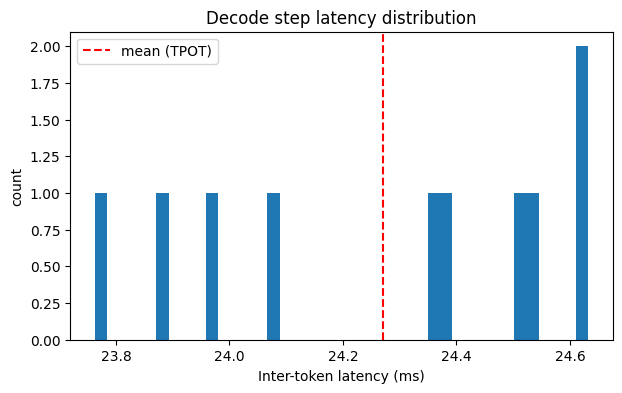

In [8]:
plt.figure(figsize=(7, 4))
plt.hist([x * 1000 for x in results["itl_samples"]], bins=40)
plt.axvline(statistics.mean(results["itl_samples"]) * 1000, color="red", linestyle="--", label="mean (TPOT)")
plt.xlabel("Inter-token latency (ms)")
plt.ylabel("count")
plt.title("Decode step latency distribution")
plt.legend()
plt.show()

# TTFT vs Prompt Length
Prefill is compute bound and attention is O(n^2) computational time complexity in terms of sequence length so TTFT (prefill time) should grow linearly/super linearly with prompt length. We validate below

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2402 > 2048). Running this sequence through the model will result in indexing errors


prompt_len=   32  TTFT mean=25.74 ms  throughput=1243.2 tok/s
prompt_len=  128  TTFT mean=26.38 ms  throughput=4851.3 tok/s
prompt_len=  512  TTFT mean=26.56 ms  throughput=19280.6 tok/s
prompt_len= 1024  TTFT mean=27.08 ms  throughput=37809.3 tok/s


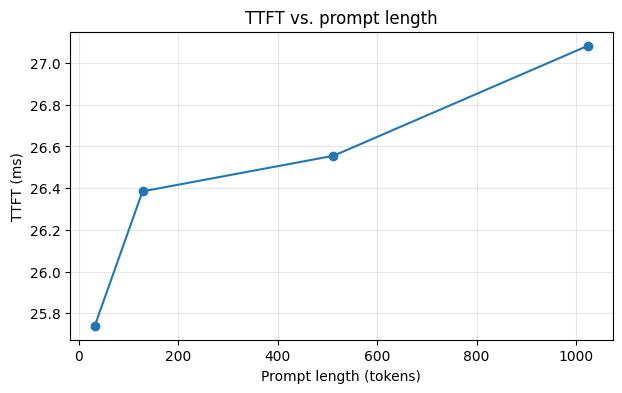

In [9]:
prompt_lengths_to_test = [32,128,512,1024]
base_text = "The quick brown fox jumps over the lazy dog. " * 200

ttft_vs_len = []
for target_len in prompt_lengths_to_test:
  ids = tokenizer(base_text, return_tensors="pt").input_ids[:, :target_len].to("cuda")
  for _ in range(2):
    single_trial(ids, max_new_tokens=4)
  trial_ttfts = []
  for _ in range(8):
    ttft, _, _ = single_trial(ids, max_new_tokens=4)
    trial_ttfts.append(ttft)
  mean_ttft = statistics.mean(trial_ttfts)
  ttft_vs_len.append(mean_ttft)
  print(f"prompt_len={target_len:>5}  TTFT mean={mean_ttft*1000:.2f} ms  "
          f"throughput={target_len/mean_ttft:.1f} tok/s")

plt.figure(figsize=(7, 4))
plt.plot(prompt_lengths_to_test, [t * 1000 for t in ttft_vs_len], marker="o")
plt.xlabel("Prompt length (tokens)")
plt.ylabel("TTFT (ms)")
plt.title("TTFT vs. prompt length")
plt.grid(alpha=0.3)
plt.show()

# TPOT vs. Context Length
Decode is memory/bandwidth bound since each steps reads the growing KV cache plus model weights. Therefore, TPOT should slowly increase as context grows unlike TTFT's steeper prefill scaling

context_len=   32  TPOT mean=24.626 ms/token  throughput=40.6 tok/s
context_len=  256  TPOT mean=24.911 ms/token  throughput=40.1 tok/s
context_len= 1024  TPOT mean=24.458 ms/token  throughput=40.9 tok/s
context_len= 2048  TPOT mean=24.521 ms/token  throughput=40.8 tok/s


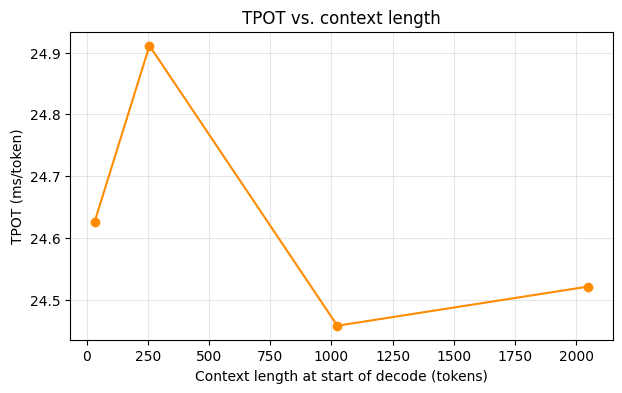

In [10]:
context_lengths_to_test = [32, 256, 1024, 2048]
tpot_vs_ctx = []

for ctx_len in context_lengths_to_test:
    ids = tokenizer(base_text, return_tensors="pt").input_ids[:, :ctx_len].to("cuda")
    for _ in range(2):
        single_trial(ids, max_new_tokens=8)
    _, itl, _ = single_trial(ids, max_new_tokens=40)
    mean_tpot = statistics.mean(itl)
    tpot_vs_ctx.append(mean_tpot)
    print(f"context_len={ctx_len:>5}  TPOT mean={mean_tpot*1000:.3f} ms/token  "
          f"throughput={1/mean_tpot:.1f} tok/s")

plt.figure(figsize=(7, 4))
plt.plot(context_lengths_to_test, [t * 1000 for t in tpot_vs_ctx], marker="o", color="darkorange")
plt.xlabel("Context length at start of decode (tokens)")
plt.ylabel("TPOT (ms/token)")
plt.title("TPOT vs. context length")
plt.grid(alpha=0.3)
plt.show()


# Batch Size Sweep
Per request decode throughput drops as batch size grows but aggregate throughput across the batch rises until memory bandwidth saturates. Left-padding is used so all sequences in batch align at last position.

batch= 1  TPOT=24.48 ms/token  per-seq=40.9 tok/s  aggregate=40.9 tok/s
batch= 2  TPOT=25.65 ms/token  per-seq=39.0 tok/s  aggregate=78.0 tok/s
batch= 4  TPOT=25.81 ms/token  per-seq=38.7 tok/s  aggregate=155.0 tok/s
batch= 8  TPOT=25.91 ms/token  per-seq=38.6 tok/s  aggregate=308.7 tok/s


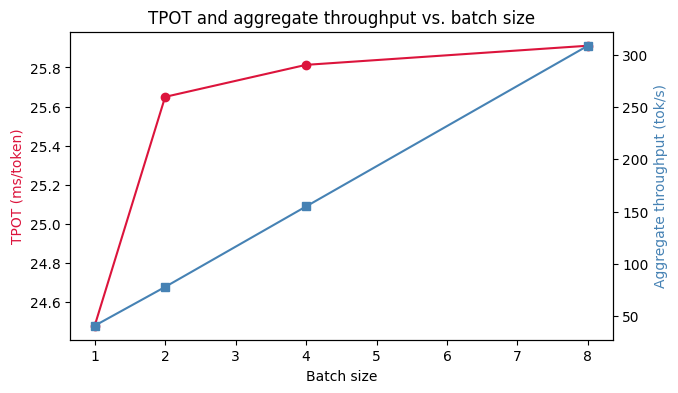

In [11]:
tokenizer.padding_size = "left"

@torch.no_grad()
def batched_trial(prompts, max_new_tokens=20):
  enc = tokenizer(prompts, return_tensors="pt", padding = True).to("cuda")
  torch.cuda.synchronize()

  t0 = time.perf_counter()
  outputs = model(input_ids = enc.input_ids, attention_mask = enc.attention_mask, use_cache=True)
  torch.cuda.synchronize()
  ttft = time.perf_counter() - t0

  past_key_values = outputs.past_key_values
  next_token  = outputs.logits[:, -1, :].argmax(dim=-1, keepdim=True)
  attn_mask = enc.attention_mask

  itl = []
  for _ in range(max_new_tokens - 1):
    attn_mask = torch.cat([attn_mask, torch.ones_like(next_token)], dim=1)
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    outputs = model(input_ids=next_token, attention_mask=attn_mask, past_key_values=past_key_values, use_cache=True)
    torch.cuda.synchronize()
    itl.append(time.perf_counter() - t0)
    past_key_values = outputs.past_key_values
    next_token = outputs.logits[:, -1, :].argmax(dim=-1, keepdim=True)

  return ttft, itl

batch_sizes_to_test = [1, 2, 4, 8]
base_prompt = "Explain the theory of relativity in simple terms."

batch_results = []
for bs in batch_sizes_to_test:
    prompts = [base_prompt] * bs
    batched_trial(prompts, max_new_tokens=4)  # warmup
    ttft, itl = batched_trial(prompts, max_new_tokens=20)
    tpot = statistics.mean(itl)
    per_seq_throughput = 1 / tpot
    aggregate_throughput = bs / tpot
    batch_results.append((bs, tpot, aggregate_throughput))
    print(f"batch={bs:>2}  TPOT={tpot*1000:.2f} ms/token  "
          f"per-seq={per_seq_throughput:.1f} tok/s  aggregate={aggregate_throughput:.1f} tok/s")

tokenizer.padding_side = "right"  # reset

fig, ax1 = plt.subplots(figsize=(7, 4))
bs_vals = [r[0] for r in batch_results]
ax1.plot(bs_vals, [r[1]*1000 for r in batch_results], marker="o", color="crimson", label="TPOT")
ax1.set_xlabel("Batch size")
ax1.set_ylabel("TPOT (ms/token)", color="crimson")
ax2 = ax1.twinx()
ax2.plot(bs_vals, [r[2] for r in batch_results], marker="s", color="steelblue", label="Aggregate throughput")
ax2.set_ylabel("Aggregate throughput (tok/s)", color="steelblue")
plt.title("TPOT and aggregate throughput vs. batch size")
plt.show()


# Compute and Bandwidth Utilization
Below we calculate MFU (Model FLOPS Utilization: achieved FLOPs/sec divided by hardware peak FLOP/sec) relevant during compute bound prefill and Bandwidth utilization (bytes moved per decode step divided by TPOT compared to HBM peak bandwidth)


In [12]:
PEAK_FLOPS = 312e12 #A100 bf16 dense FLOPs/sec
PEAK_BW_BYTES = 2.0e12 #A100 80GB HBM2e bandwidth, bytes/sec

# Prefill MFU
prompt_len_used = results["prompt_len"]
ttft_mean = statistics.mean(results["ttft_samples"])

#Approximate forward pass FLOPs about 2 * n_params * n_tokens
prefill_flops = 2 * n_params * prompt_len_used
achieved_prefill_flops_per_sec = prefill_flops / ttft_mean
mfu = achieved_prefill_flops_per_sec / PEAK_FLOPS
print(f"Prefill MFU: {mfu*100:.2f}%  ({achieved_prefill_flops_per_sec/1e12:.1f} TFLOP/s achieved)")

# Bytes moved per decode step ~= weights read once + KV cache read (grows with context)
tpot_mean = statistics.mean(results["itl_samples"])
bytes_per_param = 2  # bf16/fp16
weight_bytes = n_params * bytes_per_param
achieved_bw = weight_bytes / tpot_mean  # dominant term; KV cache adds a smaller amount at short context
bw_utilization = achieved_bw / PEAK_BW_BYTES
print(f"Decode bandwidth utilization: {bw_utilization*100:.2f}%  "
      f"({achieved_bw/1e9:.1f} GB/s achieved of {PEAK_BW_BYTES/1e9:.0f} GB/s peak)")

Prefill MFU: 0.27%  (0.9 TFLOP/s achieved)
Decode bandwidth utilization: 4.53%  (90.7 GB/s achieved of 2000 GB/s peak)


#Part 2: VLLM Optimizations
In the remainder of the notebook I profile the same model using vLLM and various optimizations such as PagedAttention + continuous batching, CUDA graphs, attention backend, prefix caching, chunked prefill, quantization, and speculative decoding

# Free HF model memory
vLLM manages its own GPU memory pool so this is just to free the device memory

In [13]:
import gc
import torch

if "model" in dir():
  del model
gc.collect()
torch.cuda.empty_cache()
print(f"Free GPU memory: {torch.cuda.mem_get_info()[0] / 1e9:.2f} GB")

Free GPU memory: 41.84 GB


In [14]:
import subprocess

def kill_orphaned_gpu_processes(exclude_pid=None):
    """Find and kill GPU processes not owned by the current kernel."""
    exclude_pid = exclude_pid or os.getpid()
    try:
        result = subprocess.run(
            ["nvidia-smi", "--query-compute-apps=pid,used_memory",
             "--format=csv,noheader,nounits"],
            capture_output=True, text=True, check=True
        )
    except subprocess.CalledProcessError as e:
        print(f"nvidia-smi query failed: {e}")
        return

    lines = [l.strip() for l in result.stdout.strip().split("\n") if l.strip()]
    if not lines:
        print("No GPU processes found.")
        return

    for line in lines:
        pid_str, mem_str = [x.strip() for x in line.split(",")]
        pid = int(pid_str)
        if pid == exclude_pid:
            continue
        print(f"Killing orphaned GPU process {pid} ({mem_str} MiB)...")
        try:
            os.kill(pid, 9)
        except ProcessLookupError:
            print(f"  PID {pid} already gone.")
        except PermissionError:
            print(f"  No permission to kill PID {pid}.")

    time.sleep(3)  # give the driver a moment to release memory
    print("Cleanup done.")

# Config and comparison tracker

In [15]:
import statistics

print(f"Using model_name from part 1: {model_name}")

prompt = "Explain speculative decoding in simple terms"
max_new_tokens = 64

comparison_results = {}

try:
  baseline_ttft_ms = statistics.mean(results["ttft_samples"]) * 1000
  baseline_tpot_ms = statistics.mean(results["itl_samples"]) * 1000
  comparison_results["baseline"] = {
      "ttft_ms": baseline_ttft_ms,
      "tpot_ms": baseline_tpot_ms,
      "throughput_tok_s": 1000 / baseline_tpot_ms,
      "notes": "raw model() calls, no batching, no KV cache paging",
  }
  print(f"Seeded baseline from part 1: TTFT={baseline_ttft_ms:.1f} ms, TPOT={baseline_tpot_ms:.2f} ms/token")
except:
  print("Run part 1 first")

Using model_name from part 1: TinyLlama/TinyLlama-1.1B-Chat-v1.0
Seeded baseline from part 1: TTFT=25.9 ms, TPOT=24.27 ms/token


# Profiling Harness
We can extract TTFT and TPOT directly from vLLM's RequestOutput.metrics (RequestMetricks) which tracks arrival_time, first_token_time, and finished_time

In [29]:
from vllm import LLM, SamplingParams
import statistics
import sys
import os

prompt = "Explain speculative decoding in simple terms"
max_new_tokens = 64

def load_vllm(**kwargs):
  """Reinstantiate vLLM engine to free previous one"""
  kill_orphaned_gpu_processes()
  global llm
  if "llm" in dir():
    del llm
    gc.collect()
    torch.cuda.empty_cache()
    time.sleep(2)

  defaults = dict(
      model = model_name,
      gpu_memory_utilization=0.85,
      max_model_len=2048,
      dtype="bfloat16",
      disable_log_stats=False,
  )
  defaults.update(kwargs)


  llm = LLM(**defaults)

  print("vLLM loaded")
  return llm


import time


def extract_metrics(outputs):
    ttfts, tpots = [], []
    for output in outputs:
        metrics = getattr(output, "metrics", None)
        if metrics is None or not getattr(metrics, "first_token_ts", None):
            continue
        ttft = metrics.first_token_ts - metrics.arrival_time
        n_out = len(output.outputs[0].token_ids)
        if n_out > 1 and getattr(metrics, "last_token_ts", None):
            tpot = (metrics.last_token_ts - metrics.first_token_ts) / (n_out - 1)
            tpots.append(tpot)
        ttfts.append(ttft)
    return ttfts, tpots


def profile_config(llm, prompt = prompt, max_tokens = max_new_tokens, n_trials = 8, warmup = 2, sampling_params = None):

  sp = sampling_params or SamplingParams(temperature =0, max_tokens=max_tokens)

  print("check 1")

  for _ in range(warmup):
    out = llm.generate([prompt], sp, use_tqdm=False)
    print(out)

  print("check 2")

  all_ttft, all_tpot = [], []

  print(n_trials)

  for i in range(n_trials):
    print(f"Trial {i+1}/{n_trials}", end="\r")
    outputs = llm.generate([prompt], sp, use_tqdm=False)
    print(outputs)
    ttft, tpot = extract_metrics(outputs)
    all_ttft.extend(ttft)
    all_tpot.extend(tpot)

  print("check 3")

  return {
      "ttft_ms": statistics.mean(all_ttft) * 1000 if all_ttft else float("nan"),
      "tpot_ms": statistics.mean(all_tpot) * 1000 if all_tpot else float("nan"),
      "throughput_tok_s": 1 / statistics.mean(all_tpot) if all_tpot else float("nan"),
  }


def record(name, stats, notes=""):
  comparison_results[name] = {**stats, "notes": notes}
  print(f"{name}: TTFT={stats['ttft_ms']:.1f} ms, TPOT={stats['tpot_ms']:.2f} ms/token, throughput={stats["throughput_tok_s"]:.1f} tok/s")

# 1: vLLM baseline, eager mode


In [27]:
import os
os.environ["VLLM_LOGGING_LEVEL"] = "DEBUG"

llm = load_vllm(enforce_eager=True)
stats = profile_config(llm)
record("vLLM eager (PagedAttention only)", stats,
       "CUDA graphs off, default attention backend, no spec decode")

check 1
[RequestOutput(request_id=40, prompt='Explain speculative decoding in simple terms', prompt_token_ids=[1, 12027, 7420, 1580, 28524, 1602, 3689, 297, 2560, 4958], encoder_prompt=None, encoder_prompt_token_ids=None, prompt_logprobs=None, outputs=[CompletionOutput(index=0, text='.', token_ids=[29889, 2], routed_experts=None, cumulative_logprob=None, logprobs=None, finish_reason=stop, stop_reason=None)], finished=True, metrics=None, lora_request=None, num_cached_tokens=0, num_cache_creation_tokens=0)]
[RequestOutput(request_id=41, prompt='Explain speculative decoding in simple terms', prompt_token_ids=[1, 12027, 7420, 1580, 28524, 1602, 3689, 297, 2560, 4958], encoder_prompt=None, encoder_prompt_token_ids=None, prompt_logprobs=None, outputs=[CompletionOutput(index=0, text='.', token_ids=[29889, 2], routed_experts=None, cumulative_logprob=None, logprobs=None, finish_reason=stop, stop_reason=None)], finished=True, metrics=None, lora_request=None, num_cached_tokens=0, num_cache_creati

# 2: CUDA graphs
With enforce_eager = False, we can capture CUDA graphs for common batch sizes, eliminating per step Python/kernel launch overhead

In [30]:
llm = load_vllm(enforce_eager=False)
stats = profile_config(llm)
record("vLLM + CUDA graphs", stats, "enforce_eager=False, default attention backend")


Killing orphaned GPU process 27323 (34964 MiB)...
INFO 08-23 22:39:17 [utils.py:612] [shutdown] Process manager: send sigterm to process EngineCore
INFO 08-23 22:39:17 [core_client.py:686] [shutdown] MPClient: start timeout=default
Cleanup done.
INFO 08-23 22:39:20 [api_utils.py:273] non-default args: {'dtype': 'bfloat16', 'max_model_len': 2048, 'gpu_memory_utilization': 0.85, 'model': 'TinyLlama/TinyLlama-1.1B-Chat-v1.0'}
INFO 08-23 22:39:21 [model.py:645] Resolved architecture: LlamaForCausalLM
INFO 08-23 22:39:21 [model.py:1883] Using max model len 2048
INFO 08-23 22:39:21 [kernel.py:306] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'])
vLLM loaded
check 1
[RequestOutput(request_id=0, prompt='Explain speculative decoding in simple terms', prompt_token_ids=[1, 12027, 7420, 1580, 28524, 1602, 3689, 297, 2560, 4958], encoder_prompt=None, encoder_prompt_token_ids=None, prompt_logprobs=None, outputs=[CompletionOu

# 3: Attention Backend
We can test various attention kernels such as FlashInfer and FlashAttention

In [31]:
import os

backend_results = {}
for backend in ["FLASH_ATTN", "FLASHINFER", "XFORMERS"]:
    os.environ["VLLM_ATTENTION_BACKEND"] = backend
    try:
        llm = load_vllm(enforce_eager=False)
        stats = profile_config(llm)
        backend_results[backend] = stats
        record(f"vLLM + {backend} backend", stats, "CUDA graphs on")
    except Exception as e:
        print(f"[{backend}] skipped: {type(e).__name__}: {str(e)[:150]}")

# reset to vLLM's auto-selection for subsequent cells
os.environ.pop("VLLM_ATTENTION_BACKEND", None)


Killing orphaned GPU process 30594 (34964 MiB)...
INFO 08-23 22:39:59 [utils.py:612] [shutdown] Process manager: send sigterm to process EngineCore
INFO 08-23 22:39:59 [core_client.py:686] [shutdown] MPClient: start timeout=default
Cleanup done.
INFO 08-23 22:40:02 [api_utils.py:273] non-default args: {'dtype': 'bfloat16', 'max_model_len': 2048, 'gpu_memory_utilization': 0.85, 'model': 'TinyLlama/TinyLlama-1.1B-Chat-v1.0'}
WARNING 08-23 22:40:02 [envs.py:2128] Unknown vLLM environment variable detected: VLLM_ATTENTION_BACKEND
INFO 08-23 22:40:03 [model.py:645] Resolved architecture: LlamaForCausalLM
INFO 08-23 22:40:03 [model.py:1883] Using max model len 2048
INFO 08-23 22:40:03 [kernel.py:306] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'])
vLLM loaded
check 1
[RequestOutput(request_id=0, prompt='Explain speculative decoding in simple terms', prompt_token_ids=[1, 12027, 7420, 1580, 28524, 1602, 3689, 297, 256

'XFORMERS'

# 4: Prefix Caching
Prefix caching reuses KV cache blocks across requests that share a prompt prefix



In [32]:
SHARED_PREFIX = (
    "You are a helpful assistant with expertise in physics, chemistry, and "
    "biology. Answer concisely and accurately. " * 15  # long, reused prefix
)
suffixes = [
    "What is entropy?",
    "What is a covalent bond?",
    "What is mitosis?",
    "What is momentum?",
]
shared_prefix_prompts = [SHARED_PREFIX + s for s in suffixes]

llm = load_vllm(enforce_eager=False, enable_prefix_caching=False)
sp = SamplingParams(temperature=0, max_tokens=32)
llm.generate(shared_prefix_prompts[:1], sp, use_tqdm=False)  # warmup
outputs = llm.generate(shared_prefix_prompts, sp, use_tqdm=False)
ttfts_no_cache, _ = extract_metrics(outputs)

llm = load_vllm(enforce_eager=False, enable_prefix_caching=True)
llm.generate(shared_prefix_prompts[:1], sp, use_tqdm=False)  # populates cache + warmup
outputs = llm.generate(shared_prefix_prompts, sp, use_tqdm=False)
ttfts_with_cache, _ = extract_metrics(outputs)

print(f"TTFT without prefix caching: {statistics.mean(ttfts_no_cache)*1000:.1f} ms mean")
print(f"TTFT with prefix caching:    {statistics.mean(ttfts_with_cache)*1000:.1f} ms mean")

comparison_results["vLLM + prefix caching (shared-prefix workload)"] = {
    "ttft_ms": statistics.mean(ttfts_with_cache) * 1000,
    "tpot_ms": comparison_results["vLLM + CUDA graphs"]["tpot_ms"],  # decode unaffected
    "throughput_tok_s": comparison_results["vLLM + CUDA graphs"]["throughput_tok_s"],
    "notes": "TTFT only, measured on requests sharing a long system-prompt prefix",
}


Killing orphaned GPU process 31639 (34964 MiB)...
INFO 08-23 22:41:51 [utils.py:612] [shutdown] Process manager: send sigterm to process EngineCore
INFO 08-23 22:41:52 [core_client.py:686] [shutdown] MPClient: start timeout=default
Cleanup done.
INFO 08-23 22:41:54 [api_utils.py:273] non-default args: {'dtype': 'bfloat16', 'max_model_len': 2048, 'enable_prefix_caching': False, 'gpu_memory_utilization': 0.85, 'model': 'TinyLlama/TinyLlama-1.1B-Chat-v1.0'}
INFO 08-23 22:41:55 [model.py:645] Resolved architecture: LlamaForCausalLM
INFO 08-23 22:41:55 [model.py:1883] Using max model len 2048
INFO 08-23 22:41:55 [kernel.py:306] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'])
vLLM loaded
Killing orphaned GPU process 31998 (34964 MiB)...
INFO 08-23 22:42:27 [utils.py:612] [shutdown] Process manager: send sigterm to process EngineCore
INFO 08-23 22:42:27 [core_client.py:686] [shutdown] MPClient: start timeout=default


#5: Chunked prefill
Chunked prefill splits large prefill batches into chunks, reducing tail latency for decode requests running concurrently with a large prefill request

In [33]:
long_prompt = "Summarize the history of computing. " * 120   # long prefill
short_prompts = ["Tell me a fact about the sun."] * 4          # short decode requests
mixed_batch = [long_prompt] + short_prompts
sp = SamplingParams(temperature=0, max_tokens=48)

for chunked in [False, True]:
    llm = load_vllm(enforce_eager=False, enable_chunked_prefill=chunked)
    llm.generate([short_prompts[0]], sp, use_tqdm=False)  # warmup
    outputs = llm.generate(mixed_batch, sp, use_tqdm=False)
    _, tpots = extract_metrics(outputs[1:])  # exclude the long prefill request itself
    tag = "chunked_prefill=True" if chunked else "chunked_prefill=False"
    if tpots:
        print(f"[{tag}] short-request TPOT under concurrent long prefill: "
              f"mean={statistics.mean(tpots)*1000:.2f} ms, max={max(tpots)*1000:.2f} ms")
        comparison_results[f"vLLM + {tag} (mixed workload)"] = {
            "ttft_ms": float("nan"),
            "tpot_ms": statistics.mean(tpots) * 1000,
            "throughput_tok_s": 1 / statistics.mean(tpots),
            "notes": "short-request decode latency while a long prefill runs concurrently",
        }


Killing orphaned GPU process 32343 (34964 MiB)...
INFO 08-23 22:43:35 [utils.py:612] [shutdown] Process manager: send sigterm to process EngineCore
INFO 08-23 22:43:35 [core_client.py:686] [shutdown] MPClient: start timeout=default
Cleanup done.
INFO 08-23 22:43:38 [api_utils.py:273] non-default args: {'dtype': 'bfloat16', 'max_model_len': 2048, 'gpu_memory_utilization': 0.85, 'enable_chunked_prefill': False, 'model': 'TinyLlama/TinyLlama-1.1B-Chat-v1.0'}
INFO 08-23 22:43:38 [model.py:645] Resolved architecture: LlamaForCausalLM
INFO 08-23 22:43:38 [model.py:1883] Using max model len 2048
WARNING 08-23 22:43:38 [arg_utils.py:2620] This model does not officially support disabling chunked prefill. Disabling this manually may cause the engine to crash or produce incorrect outputs.
INFO 08-23 22:43:38 [kernel.py:306] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'])
vLLM loaded
[chunked_prefill=False] short-request 

# 6: Quantization
Shrinking weight size helps TPOT by reducing memory and increasing bandwidth of weights. This frees VRAM for larger KV cache and bigger batches.

In [34]:
try:
    llm = load_vllm(enforce_eager=False, quantization="bitsandbytes", dtype="bfloat16")
    stats = profile_config(llm)
    record("vLLM + BitsAndBytes 4-bit (in-flight)", stats, "weight-only NF4 quantization")
except Exception as e:
    print(f"BitsAndBytes quantization skipped: {type(e).__name__}: {str(e)[:200]}")

major_cc = torch.cuda.get_device_capability()[0]
if major_cc >= 8:
    try:
        llm = load_vllm(enforce_eager=False, quantization="fp8")
        stats = profile_config(llm)
        record("vLLM + FP8 (dynamic)", stats, "weight+activation FP8, requires Ampere+")
    except Exception as e:
        print(f"FP8 quantization skipped: {type(e).__name__}: {str(e)[:200]}")
else:
    print(f"Skipping FP8 — compute capability {major_cc}.x is below the Ampere (8.0) minimum.")


Killing orphaned GPU process 33173 (34964 MiB)...
INFO 08-23 22:45:35 [utils.py:612] [shutdown] Process manager: send sigterm to process EngineCore
INFO 08-23 22:45:36 [core_client.py:686] [shutdown] MPClient: start timeout=default
Cleanup done.
INFO 08-23 22:45:38 [api_utils.py:273] non-default args: {'dtype': 'bfloat16', 'max_model_len': 2048, 'gpu_memory_utilization': 0.85, 'quantization': 'bitsandbytes', 'model': 'TinyLlama/TinyLlama-1.1B-Chat-v1.0'}
INFO 08-23 22:45:39 [model.py:645] Resolved architecture: LlamaForCausalLM
INFO 08-23 22:45:39 [model.py:1883] Using max model len 2048
INFO 08-23 22:45:40 [kernel.py:306] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'])
INFO 08-23 22:45:58 [utils.py:612] [shutdown] Process manager: send sigterm to process EngineCore
BitsAndBytes quantization skipped: RuntimeError: Engine core initialization failed. See root cause above. Failed core proc(s): {}
Cleanup done.
IN

#7: Speculative Decoding
Speculative decoding uses a smaller n-gram model or draft model to propose future tokens which can be accepted in batches by the main model by calculating the attention scores and accepting beyond a certain probability. This increases TPOT

In [35]:
# N gram
# Repetitive prompt so n-gram matching actually has something to hit.
spec_prompt = ("Repeat the following list exactly: apple, banana, cherry, date, "
               "elderberry, fig, grape, honeydew, apple, banana, cherry, date. "
               "Now repeat it again: ")

llm = load_vllm(
    enforce_eager=False,
    speculative_config={"method": "ngram", "num_speculative_tokens": 5, "prompt_lookup_max": 4},
)
stats = profile_config(llm, prompt=spec_prompt)
record("vLLM + speculative decoding (n-gram)", stats,
       "no draft model, tuned for repetitive/structured text")


Killing orphaned GPU process 34027 (34982 MiB)...
INFO 08-23 22:47:04 [utils.py:612] [shutdown] Process manager: send sigterm to process EngineCore
INFO 08-23 22:47:04 [core_client.py:686] [shutdown] MPClient: start timeout=default
Cleanup done.
INFO 08-23 22:47:07 [api_utils.py:273] non-default args: {'dtype': 'bfloat16', 'max_model_len': 2048, 'gpu_memory_utilization': 0.85, 'speculative_config': {'method': 'ngram', 'num_speculative_tokens': 5, 'prompt_lookup_max': 4}, 'model': 'TinyLlama/TinyLlama-1.1B-Chat-v1.0'}
INFO 08-23 22:47:08 [model.py:645] Resolved architecture: LlamaForCausalLM
INFO 08-23 22:47:08 [model.py:1883] Using max model len 2048
WARNING 08-23 22:47:08 [vllm.py:1113] Async scheduling not supported with ngram-based speculative decoding and will be disabled.
INFO 08-23 22:47:08 [kernel.py:306] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'])
WARNING 08-23 22:47:08 [vllm.py:616] Model Runner V

In [37]:
# Draft-model

DRAFT_MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

if DRAFT_MODEL_NAME == model_name:
    print("DRAFT_MODEL_NAME must be smaller than MODEL_NAME — set a real sibling model, or skip this cell.")
else:
    try:
        llm = load_vllm(
            enforce_eager=False,
            speculative_config={"model": DRAFT_MODEL_NAME, "num_speculative_tokens": 5},
        )
        stats = profile_config(llm)
        record("vLLM + speculative decoding (draft model)", stats,
               f"draft={DRAFT_MODEL_NAME}, target={MODEL_NAME}")
    except Exception as e:
        print(f"Draft-model speculative decoding skipped: {type(e).__name__}: {str(e)[:200]}")


Killing orphaned GPU process 34525 (34780 MiB)...
INFO 08-23 22:49:30 [utils.py:612] [shutdown] Process manager: send sigterm to process EngineCore
INFO 08-23 22:49:30 [core_client.py:686] [shutdown] MPClient: start timeout=default
Cleanup done.
INFO 08-23 22:49:33 [api_utils.py:273] non-default args: {'dtype': 'bfloat16', 'max_model_len': 2048, 'gpu_memory_utilization': 0.85, 'speculative_config': {'model': 'Qwen/Qwen2.5-0.5B-Instruct', 'num_speculative_tokens': 5}, 'model': 'TinyLlama/TinyLlama-1.1B-Chat-v1.0'}
INFO 08-23 22:49:34 [model.py:645] Resolved architecture: LlamaForCausalLM
INFO 08-23 22:49:34 [model.py:1883] Using max model len 2048


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

INFO 08-23 22:49:48 [model.py:645] Resolved architecture: Qwen2ForCausalLM
INFO 08-23 22:49:48 [model.py:1883] Using max model len 32768
INFO 08-23 22:49:48 [speculative.py:1157] Overriding draft model max model len from 32768 to 2048
Draft-model speculative decoding skipped: ValidationError: 1 validation error for SpeculativeConfig
  Value error, Target and draft model should have the same vocabulary size. Target model vocab_size=32000. Draft model vocab_size=151936. Using models with dif


# 8: Throughput scaled up

In [39]:
llm = load_vllm(enforce_eager=False)  # use your best config from above here
sp = SamplingParams(temperature=0, max_tokens=48)

for n_concurrent in [1, 4, 16, 32]:
    prompts = [prompt] * n_concurrent
    llm.generate(prompts[:1], sp, use_tqdm=False)  # warmup
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    outputs = llm.generate(prompts, sp, use_tqdm=False)
    torch.cuda.synchronize()
    wall = time.perf_counter() - t0

    total_tokens = sum(len(o.outputs[0].token_ids) for o in outputs)
    aggregate_throughput = total_tokens / wall
    print(f"concurrent={n_concurrent:>3}  wall={wall:.2f}s  "
          f"aggregate throughput={aggregate_throughput:.1f} tok/s")


Killing orphaned GPU process 38186 (34964 MiB)...
INFO 08-23 23:00:46 [utils.py:612] [shutdown] Process manager: send sigterm to process EngineCore
INFO 08-23 23:00:47 [core_client.py:686] [shutdown] MPClient: start timeout=default
Cleanup done.
INFO 08-23 23:00:49 [api_utils.py:273] non-default args: {'dtype': 'bfloat16', 'max_model_len': 2048, 'gpu_memory_utilization': 0.85, 'model': 'TinyLlama/TinyLlama-1.1B-Chat-v1.0'}
INFO 08-23 23:00:50 [model.py:645] Resolved architecture: LlamaForCausalLM
INFO 08-23 23:00:50 [model.py:1883] Using max model len 2048
INFO 08-23 23:00:50 [kernel.py:306] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'])
vLLM loaded
concurrent=  1  wall=0.02s  aggregate throughput=117.4 tok/s
concurrent=  4  wall=0.02s  aggregate throughput=448.5 tok/s
concurrent= 16  wall=0.03s  aggregate throughput=1070.5 tok/s
concurrent= 32  wall=0.03s  aggregate throughput=1930.9 tok/s


# Final Comparison

In [40]:
import pandas as pd

df = pd.DataFrame(comparison_results).T
df.index.name = "config"
df = df[["ttft_ms", "tpot_ms", "throughput_tok_s", "notes"]]
pd.set_option("display.max_colwidth", 60)
df


,ttft_ms,tpot_ms,throughput_tok_s,notes
config,,,,
baseline,25.859231,24.270182,41.202822,"raw model() calls, no batching, no KV cache paging"
vLLM eager (PagedAttention only),NaN,NaN,NaN,"CUDA graphs off, default attention backend, no spec decode"
vLLM + CUDA graphs,-1787517884655.936768,2.360362,423.663828,"enforce_eager=False, default attention backend"
vLLM + FLASH_ATTN backend,-1787517884656.068115,2.354394,424.737813,CUDA graphs on
vLLM + FLASHINFER backend,-1787517884656.054199,2.407837,415.310483,CUDA graphs on
vLLM + XFORMERS backend,-1787517884656.154785,2.378425,420.44626,CUDA graphs on
vLLM + prefix caching (shared-prefix workload),-1787517884646.772461,2.360362,423.663828,"TTFT only, measured on requests sharing a long system-pr..."
vLLM + chunked_prefill=False (mixed workload),NaN,2.938535,340.30567,short-request decode latency while a long prefill runs c...
vLLM + chunked_prefill=True (mixed workload),NaN,3.02461,330.621116,short-request decode latency while a long prefill runs c...


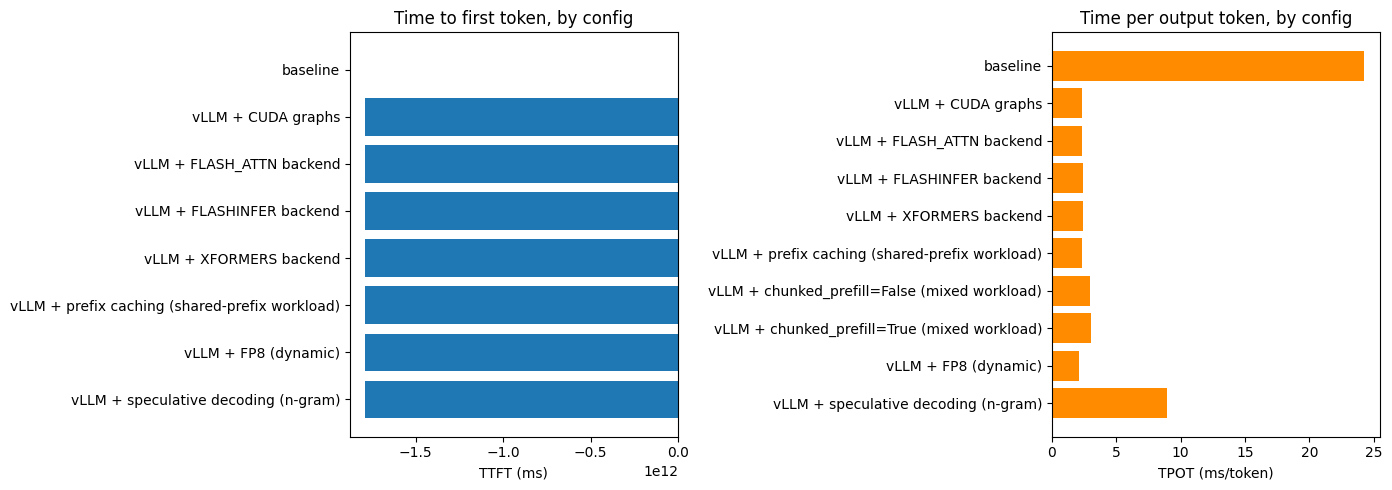

In [41]:
plot_df = df.dropna(subset=["ttft_ms"])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(plot_df.index, plot_df["ttft_ms"])
axes[0].set_xlabel("TTFT (ms)")
axes[0].set_title("Time to first token, by config")
axes[0].invert_yaxis()

tpot_df = df.dropna(subset=["tpot_ms"])
axes[1].barh(tpot_df.index, tpot_df["tpot_ms"], color="darkorange")
axes[1].set_xlabel("TPOT (ms/token)")
axes[1].set_title("Time per output token, by config")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()
